In [32]:
import ee
import geemap
import folium 
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import datetime

ee.Authenticate()
ee.Initialize()

In [2]:
gdf = gpd.read_file('./data/indigenous_protected_area.geojson')

In [3]:
gdf = gdf[gdf.terrai_nome == 'Rio Pindaré']
ee_geometry = geemap.geopandas_to_ee(gdf)

In [4]:
def rvi(image):
    '''Radar Vegetation Index'''
    vh = image.select('VH')
    vv = image.select('VV')
    rvi =  vh.multiply(4.0).divide(vv.add(vh)).rename('rvi')
    return image.addBands(rvi)


def sar_ratio(image):
    '''VV/VH'''
    ratio = image.select('VV').divide(image.select('VH')).rename('VV/VH')
    return image.addBands(ratio)

def linear_scale_db(image):
    '''Convert dB to Linear Scale'''
    return ee.Image(10).pow(image.divide(10))

def smooth(image, size = 15, format = 'square', unit = 'meters'):
    '''Smooth Image with Focal Median Filter'''
    return image.focalMedian(size, format, unit)

In [5]:
S1 = ee.ImageCollection(
    "COPERNICUS/S1_GRD")\
    .filterBounds(ee_geometry)\
    .filterDate("2025-01-01", "2025-11-01")\
    .filter(ee.Filter.eq('orbitProperties_pass','DESCENDING'))\
    .select(['VV', 'VH'])


In [ ]:
# Correcting image and generating RVI
rviCollection_linear = S1.map(linear_scale_db).map(rvi)
rviSmoothed_median = rviCollection_linear.map(smooth).median().clip(ee_geometry)

In [7]:
rviCollection_linear

In [8]:
mean_vv = S1.select('VV').median() 
mean_vh = S1.select('VH').median()

rgb_composite = ee.Image.rgb(
   mean_vv,
   mean_vh,
   mean_vv.divide(mean_vh) # VV/VH Ratio
).clip(ee_geometry)


In [9]:
sar_vis_params = {'min':[-25, -25, 0] ,'max':[0, 0, 2]};


m = geemap.Map(zoom_start = 12)

m.addLayer(
   rgb_composite, 
    sar_vis_params, # Use the three-valued parameter set
    'RGB Composite'
    )

m.addLayer(
    rviSmoothed_median.select('rvi'),
    {'min': 0.02, 'max': 0.98,
    'palette': ['blue', 'yellow', '008000', '004000']},
    'RVI (Smoothed)'
)

m.addLayerControl()

m.centerObject(ee_geometry)

m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [35]:
def reduce_region(image):
    median_rvi = image.reduceRegion(
        reducer = ee.Reducer.median(),
        geometry = ee_geometry,
        scale = 30
    ).get('rvi')

    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')

    return ee.Feature(
        None, 
        properties = {
            'date': date,
            'median_rvi': median_rvi
        } )



In [37]:
filtered_collection = S1.map(rvi).filterBounds(ee_geometry)
rvi_timeseries = filtered_collection.map(reduce_region)
rvi_timeseries

In [38]:
valid_timeseries = rvi_timeseries.filter(ee.Filter.notNull(['median_rvi']))

# Now aggregate using the filtered collection
rvi_values = valid_timeseries.aggregate_array('median_rvi').getInfo()
rvi_dates = valid_timeseries.aggregate_array('date').getInfo()
rvi_dates = [datetime.datetime.strptime(d, '%Y-%m-%d') for d in rvi_dates ]

print("Valid RVI Values:", rvi_values)
print("Valid Dates:", rvi_dates)

Valid RVI Values: [2.4921217603123624, 2.507855862215365, 2.4922487067032244, 2.5078795823969, 2.492106999643534, 2.5078272582035153, 2.507728577391334, 2.507926342675766, 2.5233082518105805, 2.507892122646843, 2.523364362480334, 2.5157632332488493, 2.5234614987129538, 2.5235027696078887, 2.523340861485763, 2.554561745852944, 2.5390882883177293, 2.5078049534513975, 2.523424194709047, 2.5390599512806222, 2.50780503561596, 2.5234193658339565, 2.5079127048988545, 2.492146263428096, 2.439316946820582]
Valid Dates: [datetime.datetime(2025, 1, 6, 0, 0), datetime.datetime(2025, 1, 18, 0, 0), datetime.datetime(2025, 1, 30, 0, 0), datetime.datetime(2025, 2, 11, 0, 0), datetime.datetime(2025, 2, 23, 0, 0), datetime.datetime(2025, 3, 7, 0, 0), datetime.datetime(2025, 3, 19, 0, 0), datetime.datetime(2025, 3, 31, 0, 0), datetime.datetime(2025, 4, 12, 0, 0), datetime.datetime(2025, 4, 24, 0, 0), datetime.datetime(2025, 5, 6, 0, 0), datetime.datetime(2025, 5, 18, 0, 0), datetime.datetime(2025, 5, 30,

Text(0.5, 1.0, 'Mean RVI for Rio Pindaré Protected Area')

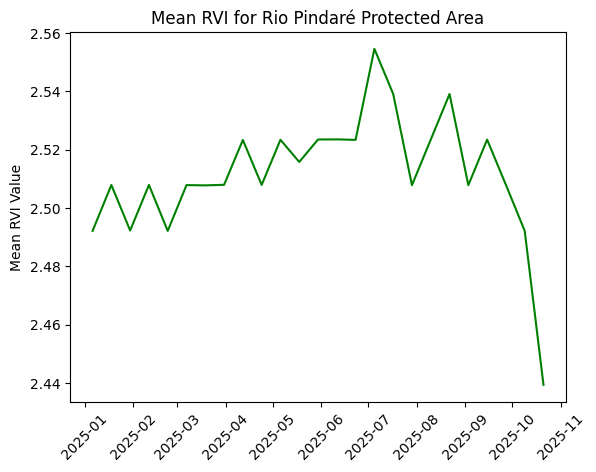

In [ ]:
plt.plot(
    rvi_dates, 
    rvi_values,
    color = 'green')
plt.xticks(rotation = 45)
plt.ylabel('RVI Value')
plt.title('RVI for Rio Pindaré Protected Area')

In [ ]:
# Next steps

## - Make Functions for Everything
## - The pipeline must generate a database where we can store the data
## - THe pipeline must generate a:
    ## - Timeseries GIF
    ## - Map difference from the 1st and last image to spot differences. (Does it make sense?)

Total number of images: 25

